In [297]:
import pathlib
import kaggle
from PIL import Image
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from matplotlib.pyplot import axis
from pandas import isna

# Xử lí nhiễu, input các thứ  + Z-score mấy cái dữ liệu lại

In [298]:
dts = pd.read_csv("dataset/Train titanic/train.csv")
dts["Start Port"]=dts["Start Port"].map({
    "S": 0,
    "Q": 1,
    "C": 2
})
dts["Sex"]=dts["Sex"].map({
    "male": 0,
    "female": 1
})
dts["Start Port"]=dts["Start Port"].fillna(dts["Start Port"].quantile(0.5))
dts["Age"] = dts["Age"].astype(float)
q1 = dts["Age"].quantile(0.25)
q3 = dts["Age"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
dts["Age"]=dts["Age"].fillna(dts["Age"].quantile(0.5))
survive=dts["Survived"]
dts = dts.drop(columns=["Cabin","PassengerId","Name","Survived","Ticket"])
print(dts.isna().sum())
print(dts.dtypes)
column_to_scale = ["Age","Fare"]
dts[column_to_scale] = (dts[column_to_scale]-dts[column_to_scale].mean(axis=0))/dts[column_to_scale].std(axis=0)



Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Start Port    0
dtype: int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Start Port    float64
dtype: object


# Bước 1: Chia train/test

In [299]:
X_train =[]
X_test=[]
X_train_temp, X_test_temp, y_train, y_test = train_test_split(
    dts,
    survive,
    test_size=0.2,
    random_state=45
)

# Bước 2: Thêm bias

y = Wx + b

Thêm bias vào cột cuối cùng

In [300]:
X_train = np.c_[X_train_temp,np.ones(len(X_train_temp))]
X_test = np.c_[X_test_temp,np.ones(len(X_test_temp))]
print(X_train.shape)
print(X_test.shape)

(712, 8)
(179, 8)


# Bước 3: Khởi tạo trọng số

In [301]:
w = np.zeros(X_train.shape[1])

# Bước 4: Hàm sigmoid

In [302]:
def sigmoid(z):
    return 1/ (1+ np.exp(-z))

# Bước 5: Predict probability

In [303]:
def predict_proba(X, w):
    return sigmoid(X @ w)

# Bước 6: Binary Cross Entropy

In [304]:
def loss(y, y_pred):

    eps = 1e-15

    y_pred = np.clip(y_pred, eps, 1-eps) #Giới hạn giá trị của y_pred trong khoảng eps và 1-eps vì y_pred ko đc bằng 0

    return -np.mean(
        y*np.log(y_pred) +
        (1-y)*np.log(1-y_pred)
    )

# Bước 7: Gradient

In [305]:
def gradient(X, y, y_pred):

    m = len(y)

    return ((y_pred-y)@X)/m

# Bước 8: Gradient Descent

In [306]:
learning_rate = 0.01

epochs = 10000

losses = []

for epoch in range(epochs):

    y_pred = predict_proba(X_train, w)

    l = loss(y_train, y_pred)

    losses.append(l)

    grad = gradient(X_train, y_train, y_pred)

    w -= learning_rate * grad
# print(l)
zxc=[1,1,50,0,0,20,1,1]

# Bước 9: Predict

In [307]:
def predict(X, w):

    proba = predict_proba(X, w)

    return (proba >= 0.5).astype(int)


# Bước 10: Accuracy

In [308]:
y_pred = predict(X_test, w)
accuracy = np.mean(y_pred == y_test)

print(accuracy)

0.8379888268156425


# Bước 11: Confusion Matrix

In [309]:
from sklearn.metrics import confusion_matrix
     
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[102  15]
 [ 14  48]]


# Bước 12: Precision Recall F1

In [310]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       117
           1       0.76      0.77      0.77        62

    accuracy                           0.84       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179



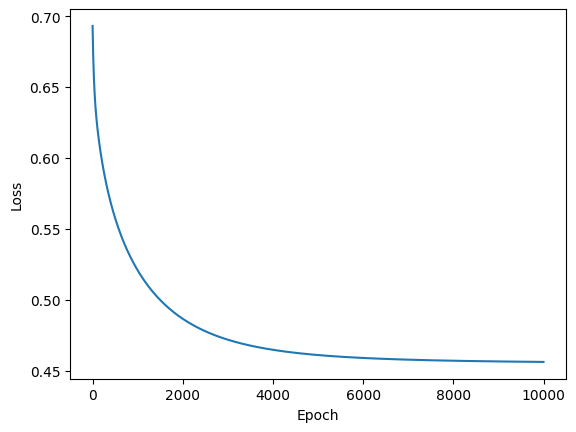

0.7879213483146067
0.8379888268156425
(179, 8)


In [311]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
train_acc = np.mean(predict(X_train, w) == y_train)

test_acc = np.mean(predict(X_test, w) == y_test)

print(train_acc)
print(test_acc)
print(X_test.shape)


# Dự đoán bằng KNN

Chọn K

In [312]:
Kkk = 5

In [ ]:
mm=[1,3,22,0,0,11,1]
prediction =[]
zxc= np.array(mm).T
zxc = zxc.reshape(1,len(zxc))
print(zxc.shape)
print(dts.shape)
for x in X_test:
    distance = np.sqrt(np.sum((X_train - x)**2, axis=1))
    idx = np.argsort(distance)
    nearest = idx[:Kkk]

    labels = np.array(y_train)[nearest]

    prediction.append(np.bincount(labels).argmax())
print(prediction)
count = np.bincount(
    
)
print("Số lượng 0:", count[0])
print("Số lượng 1:", count[1])

(1, 7)
(891, 7)
[np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64